100%|██████████| 12000/12000 [00:00<00:00, 207840.31it/s]


Visualizing sample 0


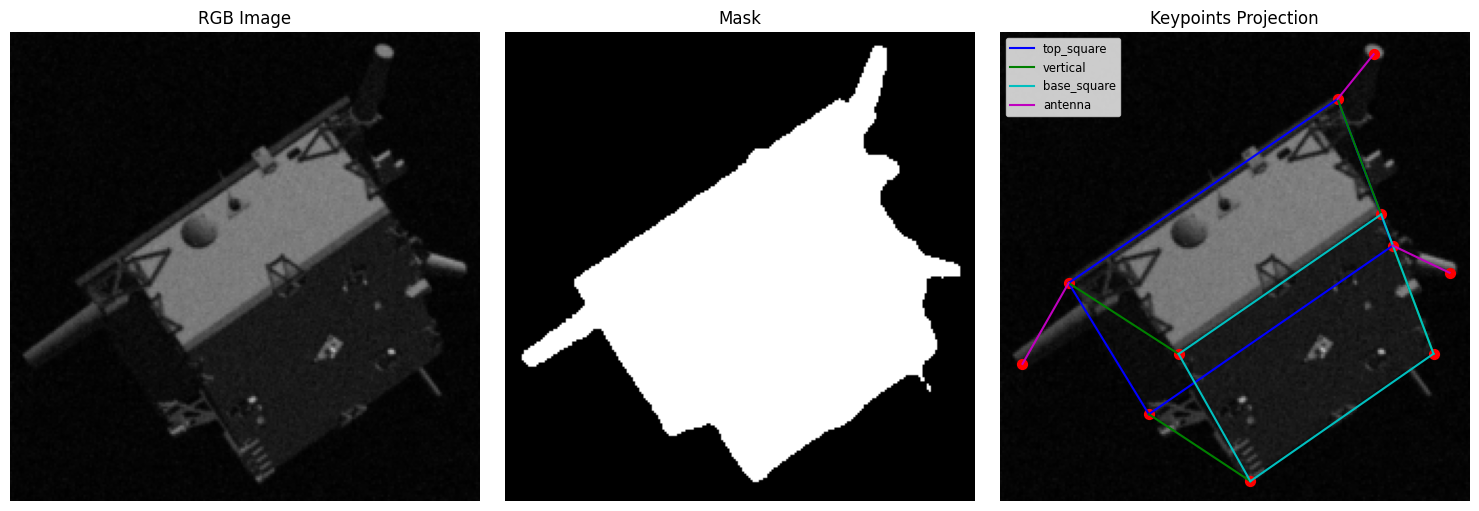

Visualizing sample 1


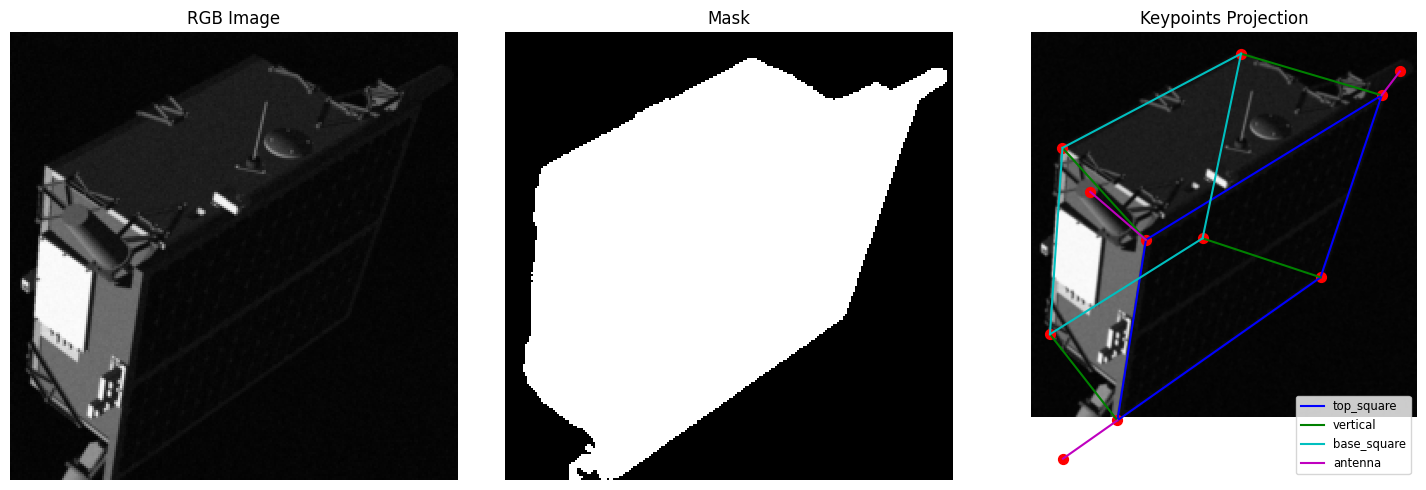

Visualizing sample 2


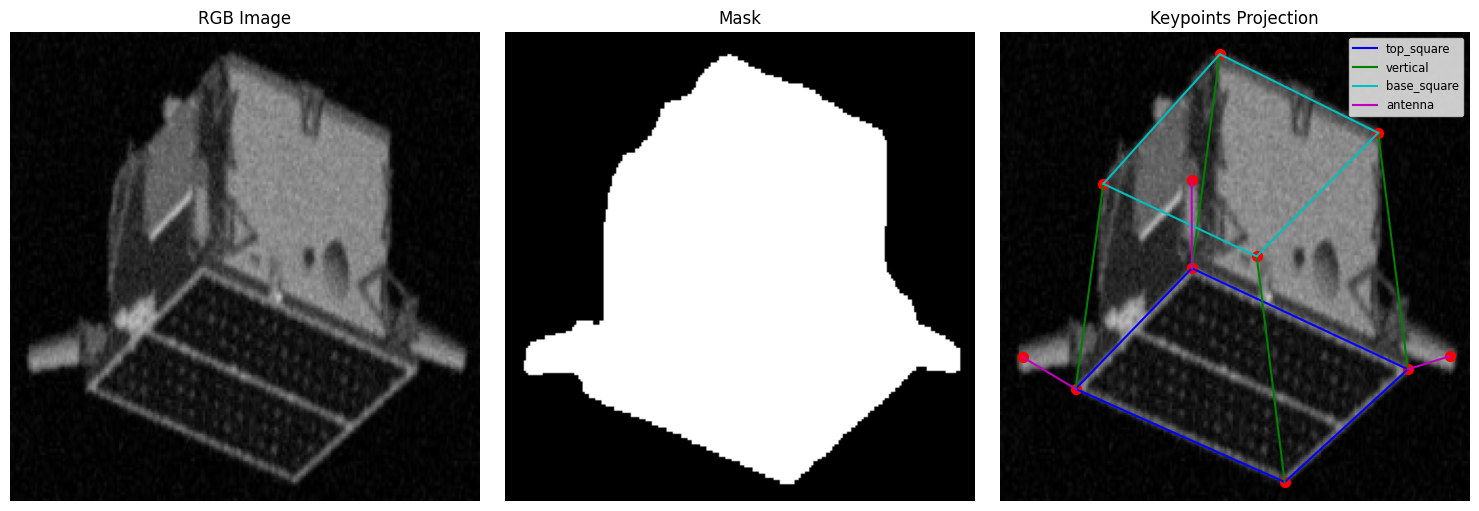

Visualizing sample 3


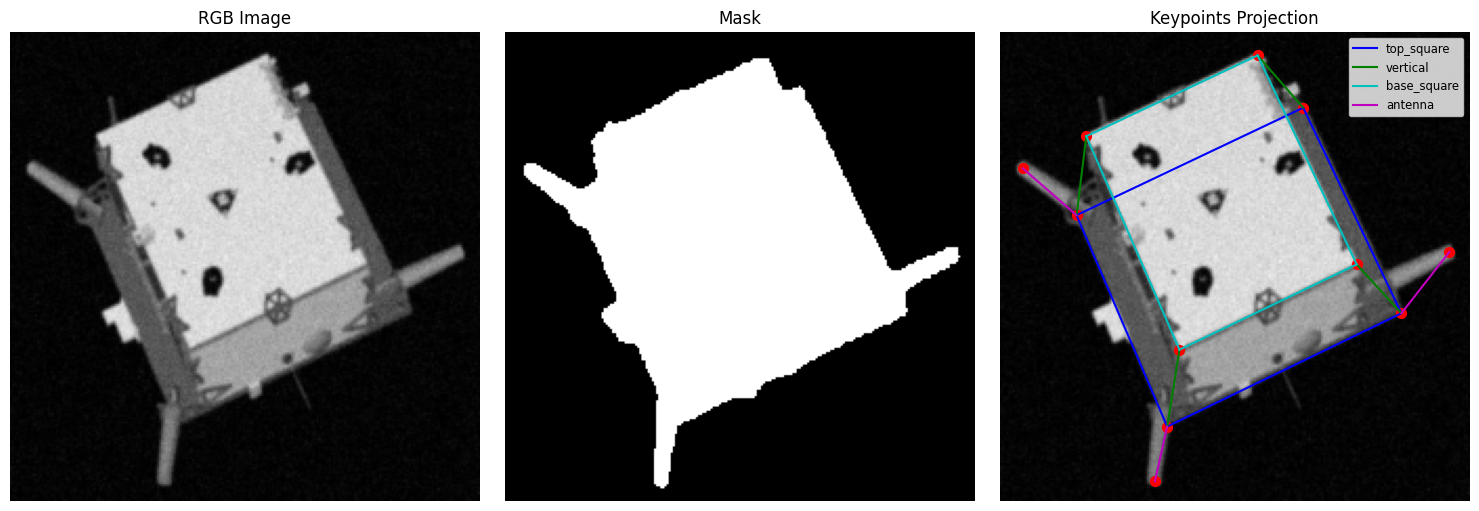

Visualizing sample 4


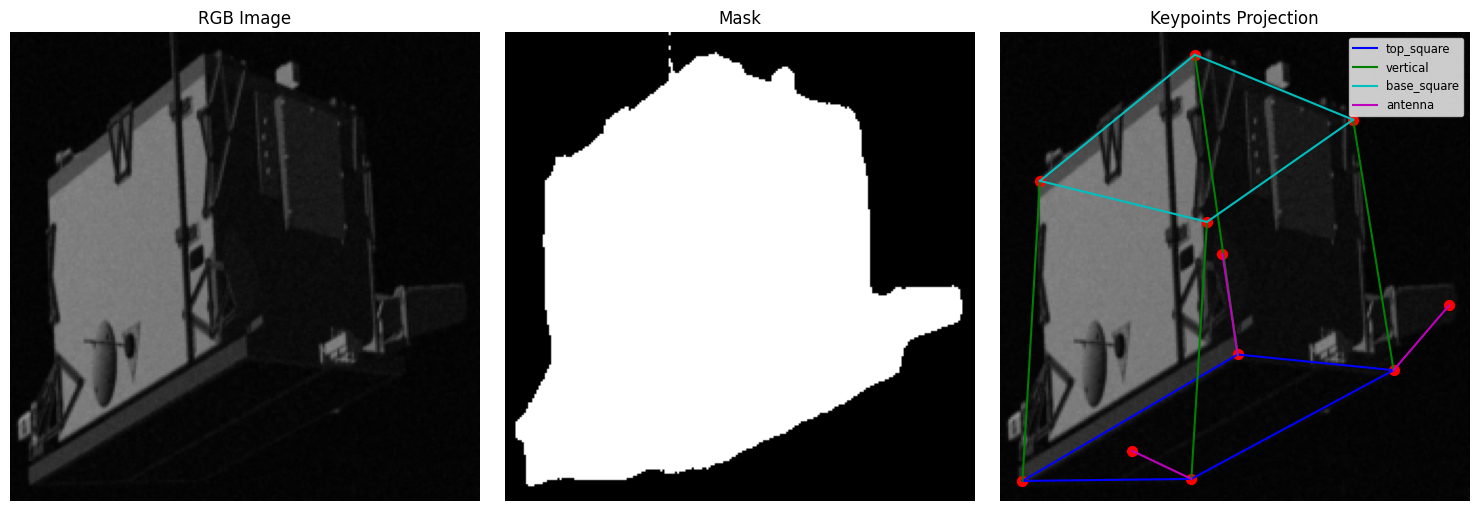

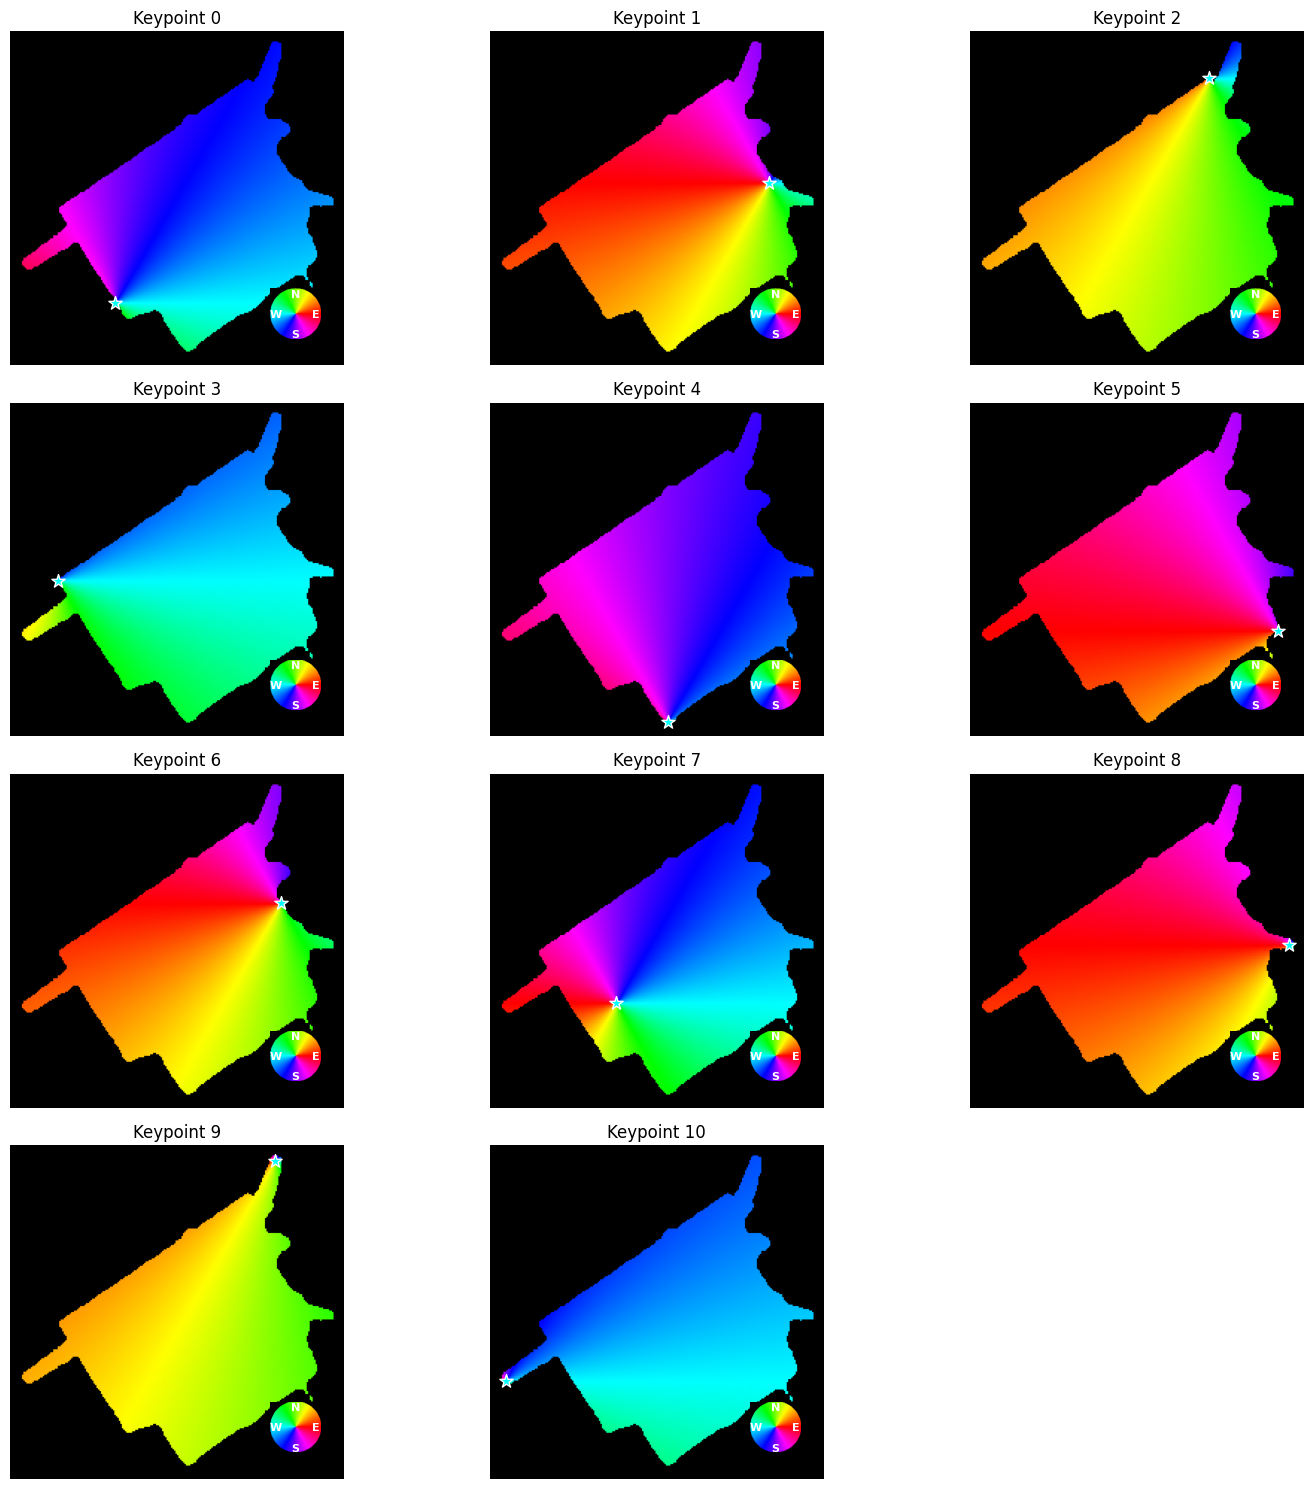

/tmp/ipykernel_19/3983263311.py:783: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to pretrained.pth/resnet18-5c106cde.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 248MB/s]
/usr/local/lib/python3.11/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


Layer (type:depth-idx)                        Output Shape              Param #
Resnet18_8s                                   [1, 2, 224, 224]          --
├─ResNet: 1-1                                 [1, 64, 112, 112]         --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 56, 56]           73,984
│    │    └─BasicBlock: 3-2                   [1, 64, 56, 56]           73,984
│    └─Sequential: 2-6                        [1, 128, 28, 28]          --
│    │    └─BasicBlock: 3-3                   [1, 128, 28, 28]          230,144
│    │    └─BasicBlock: 3-4                   [1, 128, 28, 28]          295,42

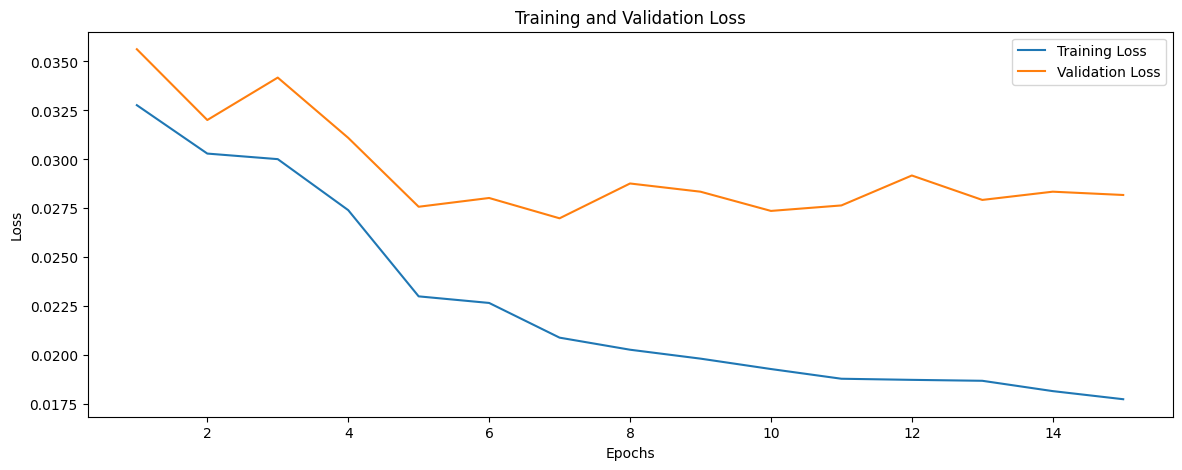

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchinfo import summary
from scipy.io import loadmat
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm
import torch.utils.model_zoo as model_zoo
import math
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb
import torchvision.transforms.functional as T

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm
 
def get_data_pts_2d(pts_3d, RT, cam_K):
    pts_2d=np.matmul(pts_3d,RT[:,:3].T)+RT[:,3:].T
    pts_2d=np.matmul(pts_2d,cam_K.T)
    pts_2d=pts_2d[:,:2]/pts_2d[:,2:]
    return pts_2d

def compute_vertex_hcoords(mask, hcoords, use_motion=False):
    h,w=mask.shape
    m=hcoords.shape[0]
    xy = np.argwhere(mask == 1)[:, [1, 0]]
    vertex = xy[:, None, :]*hcoords[None, :, 2:]
    vertex = hcoords[None, :, :2] - vertex
    if not use_motion:
        norm = np.linalg.norm(vertex, axis=2, keepdims=True)
        norm[norm<1e-3] += 1e-3
        vertex = vertex / norm

    vertex_out=np.zeros([h,w,m,2],np.float32)
    vertex_out[xy[:, 1], xy[:, 0]] = vertex
    return  np.reshape(vertex_out,[h,w,m*2])

def smooth_l1_loss(vertex_pred, vertex_targets, vertex_weights, sigma=1.0, normalize=True, reduce=True):
    '''
    :param vertex_pred:     [b,vn*2,h,w]
    :param vertex_targets:  [b,vn*2,h,w]
    :param vertex_weights:  [b,1,h,w]
    :param sigma:
    :param normalize:
    :param reduce:
    :return:
    '''
    b,ver_dim,_,_=vertex_pred.shape
    sigma_2 = sigma ** 2
    vertex_diff = vertex_pred - vertex_targets
    diff = vertex_weights * vertex_diff
    abs_diff = torch.abs(diff)
    smoothL1_sign = (abs_diff < 1. / sigma_2).detach().float()
    in_loss = torch.pow(diff, 2) * (sigma_2 / 2.) * smoothL1_sign \
              + (abs_diff - (0.5 / sigma_2)) * (1. - smoothL1_sign)

    if normalize:
        in_loss=torch.sum(in_loss.view(b,-1),1) / (ver_dim * torch.sum(vertex_weights.view(b,-1),1) + 1e-3)

    if reduce:
       torch.mean(in_loss)

    return in_loss

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

def conv3x3(in_planes, out_planes, stride=1, dilation=1):
    "3x3 convolution with padding"
    
    kernel_size = np.asarray((3, 3))
    
    # Compute the size of the upsampled filter with
    # a specified dilation rate.
    upsampled_kernel_size = (kernel_size - 1) * (dilation - 1) + kernel_size
    
    # Determine the padding that is necessary for full padding,
    # meaning the output spatial size is equal to input spatial size
    full_padding = (upsampled_kernel_size - 1) // 2
    
    # Conv2d doesn't accept numpy arrays as arguments
    full_padding, kernel_size = tuple(full_padding), tuple(kernel_size)
    
    return nn.Conv2d(in_planes, out_planes, kernel_size=kernel_size, stride=stride,
                     padding=full_padding, dilation=dilation, bias=False)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, dilation=1):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride, dilation=dilation)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes, dilation=dilation)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, dilation=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        
        self.conv2 = conv3x3(planes, planes, stride=stride, dilation=dilation)
        
        #self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
        #                       padding=1, bias=False)
        
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

class ResNet(nn.Module):

    def __init__(self,
                 block,
                 layers,
                 num_classes=1000,
                 fully_conv=False,
                 remove_avg_pool_layer=False,
                 output_stride=32):
        
        # Add additional variables to track
        # output stride. Necessary to achieve
        # specified output stride.
        self.output_stride = output_stride
        self.current_stride = 4
        self.current_dilation = 1
        
        self.remove_avg_pool_layer = remove_avg_pool_layer
        
        self.inplanes = 64
        self.fully_conv = fully_conv
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        self.avgpool = nn.AvgPool2d(7)

        self.fc = nn.Linear(512 * block.expansion, num_classes)
        
        if self.fully_conv:
            self.avgpool = nn.AvgPool2d(7, padding=3, stride=1)
            # In the latest unstable torch 4.0 the tensor.copy_
            # method was changed and doesn't work as it used to be
            #self.fc = nn.Conv2d(512 * block.expansion, num_classes, 1)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1, dilation=1):
        downsample = None
         
        if stride != 1 or self.inplanes != planes * block.expansion:
            
            # Check if we already achieved desired output stride.
            if self.current_stride == self.output_stride:
                
                # If so, replace subsampling with a dilation to preserve
                # current spatial resolution.
                self.current_dilation = self.current_dilation * stride
                stride = 1
            else:
                
                # If not, perform subsampling and update current
                # new output stride.
                self.current_stride = self.current_stride * stride
                
            # We don't dilate 1x1 convolution.
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, dilation=self.current_dilation))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes, dilation=self.current_dilation))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x2s = self.relu(x)
        x = self.maxpool(x2s)

        x4s = self.layer1(x)
        x8s = self.layer2(x4s)
        x16s = self.layer3(x8s)
        x32s = self.layer4(x16s)
        x=x32s
        
        if not self.remove_avg_pool_layer:
            x = self.avgpool(x)
        
        if not self.fully_conv:
            x = x.view(x.size(0), -1)
            
        xfc = self.fc(x)

        return x2s,x4s,x8s,x16s,x32s,xfc

def resnet18(pretrained=False, **kwargs):
    """Constructs a ResNet-18 model.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    model = ResNet(BasicBlock, [2, 2, 2, 2], **kwargs)
    if pretrained:
        model.load_state_dict(model_zoo.load_url("https://download.pytorch.org/models/resnet18-5c106cde.pth",model_dir="pretrained.pth"))
    return model

def visualize_object_with_bbox(rgb_img, mask, hcoords, figsize=(15, 5)):
    """Visualize RGB, mask, and projected keypoints"""
    plt.figure(figsize=figsize)
    
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title('RGB Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(rgb_img)
    plt.title('Keypoints Projection')
    
    points_2d = hcoords[:, :2].numpy()
    
    segments = {
        'top_square': [(0, 1), (1, 2), (2, 3), (3, 0)],  # Top square
        'vertical': [(0, 4), (1, 5), (2, 6), (3, 7)],     # Vertical connections
        'base_square': [(4, 5), (5, 6), (6, 7), (7, 4)],   # Base square
        'antenna': [(1, 8), (2, 9), (3, 10)]              # Antenna connections
    }
    
    segment_colors = {
        'top_square': 'b',   # Blue
        'vertical': 'g',      # Green
        'base_square': 'c',    # Cyan 
        'antenna': 'm'        # Magenta
    }
    
    for seg_type, connections in segments.items():
        color = segment_colors[seg_type]
        for p1_idx, p2_idx in connections:
            if p1_idx < len(points_2d) and p2_idx < len(points_2d):
                plt.plot([points_2d[p1_idx, 0], points_2d[p2_idx, 0]],
                         [points_2d[p1_idx, 1], points_2d[p2_idx, 1]],
                         f'{color}-', linewidth=1.5, label=seg_type if connections.index((p1_idx, p2_idx)) == 0 else "")
    
    plt.scatter(points_2d[:, 0], points_2d[:, 1], c='r', s=50)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='best', fontsize='small')
    
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_vertex(vertex, vertex_weights, keypoints=None):
    """
    Visualize vertex vectors with directional coloring on a black background.
    Also plots the keypoints locations if provided.
    
    Args:
        vertex: Vertex vectors [batch, channels, height, width]
        vertex_weights: Vertex weights [batch, 1, height, width]
        keypoints: Optional keypoints to plot [11, 3] (hcoords)
    """
    
    # Apply weights to vertex
    vertex = vertex * vertex_weights
    
    # Changed to 3x3 grid to accommodate 8 keypoints
    plt.figure(figsize=(15, 15))
    n_keypoints = vertex.shape[1] // 2

    # Create directional images for each keypoint
    for i in range(n_keypoints):
        ax = plt.subplot(4, 3, i+1)
        
        # Get x and y components
        vx = vertex[0, 2*i].cpu().numpy()
        vy = vertex[0, 2*i+1].cpu().numpy()
        
        # Calculate angle and magnitude
        angle = np.arctan2(vy, vx)
        magnitude = np.sqrt(vx**2 + vy**2)
        
        # Create HSV image
        h, w = vx.shape
        hsv_img = np.zeros((h, w, 3))
        
        # Calculate normalized angle (hue), but flip the angle to match the legend
        # This ensures colors in the visualization match the direction legend
        hsv_img[:, :, 0] = ((-angle + 2*np.pi) % (2*np.pi)) / (2*np.pi)  # Hue from angle
        hsv_img[:, :, 1] = 1.0  # Full saturation
        
        # Get mask of valid pixels
        mask = vertex_weights[0, 0].cpu().numpy() > 0
        
        # Set value channel (brightness)
        hsv_img[:, :, 2] = np.zeros_like(magnitude)  # Black background
        if mask.any() and magnitude[mask].max() > 0:
            hsv_img[:, :, 2][mask] = np.clip(magnitude[mask] / magnitude[mask].max(), 0, 1)
        
        # Convert to RGB
        rgb_img = hsv_to_rgb(hsv_img)
        
        plt.imshow(rgb_img)
        
        # Plot keypoint if provided
        if keypoints is not None and i < len(keypoints):
            kp_x, kp_y = int(keypoints[i, 0]), int(keypoints[i, 1])
            if 0 <= kp_x < w and 0 <= kp_y < h:
                plt.scatter(kp_x, kp_y, c='cyan', s=100, marker='*', edgecolors='white')
        
        plt.title(f'Keypoint {i}')
        plt.axis('off')

        # Add inset legend to the bottom right
        # ax_inset = ax.inset_axes([0.7, 0.05, 0.25, 0.25])
        ax_inset = ax.inset_axes([0.78, 0.08, 0.15, 0.15])  # Smaller inset, further from the image corner
        
        # Generate a color wheel
        size = 100
        center = size // 2
        y, x = np.ogrid[:size, :size]
        dist = np.sqrt((x - center)**2 + (y - center)**2)
        
        # Create a circular mask
        mask_wheel = dist <= center
        
        # Generate the color wheel
        angles = np.arctan2(center - y, x - center)
        hues = ((angles + 2*np.pi) % (2*np.pi)) / (2*np.pi)
        
        # Create HSV image
        hsv_wheel = np.zeros((size, size, 3))
        hsv_wheel[:, :, 0] = hues
        hsv_wheel[:, :, 1] = 1.0 # Use full saturation for simplicity
        hsv_wheel[:, :, 2] = mask_wheel.astype(float)
        
        # Convert to RGB
        rgb_wheel = hsv_to_rgb(hsv_wheel)
        
        ax_inset.imshow(rgb_wheel)
        ax_inset.axis('off')
        
        # Add direction labels
        directions = ['E', 'N', 'W', 'S']
        angles_text = [0, np.pi/2, np.pi, 3*np.pi/2]
        radius = center * 0.8
        
        for angle_text, direction in zip(angles_text, directions):
            x_t = center + radius * np.cos(angle_text)
            y_t = center - radius * np.sin(angle_text)
            ax_inset.text(x_t, y_t, direction, ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=8)
    
    plt.tight_layout()
    plt.show()

class SPEEDDataset(Dataset):
    def __init__(self, images_dir, json_dir, mask_dir, transform=None):
        self.transform = transform

        self.rgbPthList = []
        self.maskPthList = []
        self.frameInfoList = []
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.mask_dir = mask_dir    

        self.keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        self.cameraMatrix, self.distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }

            cnt = 0
            for filename in tqdm.tqdm(sorted(os.listdir(self.images_dir))):
                if filename not in lookup:
                    continue
                
                frame_idx = int(''.join(filter(str.isdigit, filename.split('.')[0])))
                
                pngFilename = filename.replace('.jpg', '.png')
                
                self.rgbPthList.append(os.path.join(self.images_dir, filename))
                self.maskPthList.append(os.path.join(self.mask_dir, pngFilename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                frame_info = {
                    'frame_idx': frame_idx,
                    'q_vbs2tango': q_vbs2tango,
                    'r_Vo2To_vbs': r_Vo2To_vbs
                }
                self.frameInfoList.append(frame_info)

                cnt = cnt + 1
                # if cnt>10:
                #     break

    def __len__(self):
        return len(self.rgbPthList)

    def __getitem__(self, idx):
        rgb_path = self.rgbPthList[idx]
        rgb_img = Image.open(rgb_path).convert('RGB')
        rgb_img = np.array(rgb_img)
        rgb = torch.from_numpy(rgb_img).float().permute(2, 0, 1)
        
        mask_path = self.maskPthList[idx]
        mask_img = Image.open(mask_path).convert('1')
        mask_seg = np.array(mask_img).astype(np.int32)
        mask = torch.from_numpy(mask_seg).long()
        
        frame_info = self.frameInfoList[idx]        
        keypts2d = project_keypoints(frame_info['q_vbs2tango'], frame_info['r_Vo2To_vbs'], self.cameraMatrix, self.distCoeffs, self.keypts3d).T # (11, 2)
        hcoords = np.concatenate([keypts2d, np.ones([11, 1], np.float32)], 1)

        rotation_matrix = quat2dcm(frame_info['q_vbs2tango'])
        translation_vector = frame_info['r_Vo2To_vbs'].reshape(3, 1)
        RT = np.hstack((rotation_matrix, translation_vector))

        orig_h, orig_w = mask_seg.shape

        xmin = np.min(keypts2d[:, 0])
        xmax = np.max(keypts2d[:, 0])
        ymin = np.min(keypts2d[:, 1])
        ymax = np.max(keypts2d[:, 1])

        width = xmax - xmin
        height = ymax - ymin
        margin_x = width * 0.05
        margin_y = height * 0.05

        xmin = max(0, xmin - margin_x)
        xmax = min(orig_w, xmax + margin_x)
        ymin = max(0, ymin - margin_y)
        ymax = min(orig_h, ymax + margin_y)

        xmin, xmax, ymin, ymax = map(int, [xmin, xmax, ymin, ymax])

        rgb_cropped = rgb[:, ymin:ymax, xmin:xmax]
        mask_cropped = mask[ymin:ymax, xmin:xmax]

        keypts2d_cropped = keypts2d.copy()
        keypts2d_cropped[:, 0] -= xmin
        keypts2d_cropped[:, 1] -= ymin

        hcoords_cropped = np.concatenate([keypts2d_cropped, np.ones([11, 1], np.float32)], 1)

        rgb_cropped = T.resize(rgb_cropped, [224, 224])
        mask_cropped = T.resize(mask_cropped.unsqueeze(0), [224, 224], interpolation=Image.NEAREST).squeeze(0)

        crop_h, crop_w = ymax - ymin, xmax - xmin
        scale_x = 224 / crop_w
        scale_y = 224 / crop_h

        keypts2d_resized = keypts2d_cropped.copy()
        keypts2d_resized[:, 0] *= scale_x
        keypts2d_resized[:, 1] *= scale_y

        hcoords_resized = hcoords_cropped.copy()
        hcoords_resized[:, 0] *= scale_x
        hcoords_resized[:, 1] *= scale_y

        mask_np = mask_cropped.numpy().astype(np.int32)
        ver_np = compute_vertex_hcoords(mask_np, hcoords_resized, use_motion=False)
        hcoords = torch.tensor(hcoords_resized.astype(np.float32))

        ver = torch.tensor(ver_np, dtype=torch.float32).permute(2, 0, 1)
        ver_weight = mask_cropped.unsqueeze(0).float()
        pose = torch.tensor(RT.astype(np.float32))

        return rgb_cropped, mask_cropped, ver, ver_weight, pose, hcoords
    

dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', mask_dir= '/kaggle/input/speedsplitmaskssamvit-h/speedsplit/speed/masks/trainval')
train_size= int(0.8* len(dataset))
train_data, val_data = random_split(dataset, [train_size, len(dataset) - train_size])

num_images = min(5,len(dataset))
for idx in range(num_images):
    print(f"Visualizing sample {idx}")
    rgb_sample, mask_sample, ver_sample, ver_weight_sample, pose_sample, hcoords_sample = dataset[idx]
    rgb_np = rgb_sample.permute(1, 2, 0).numpy().astype(np.uint8)
    mask_np = mask_sample.numpy()
    
    visualize_object_with_bbox(rgb_np, mask_np, hcoords_sample)

rgb_sample, mask_sample, ver_sample, ver_weight_sample, pose_sample, hcoords_sample = dataset[0]

ver_sample = ver_sample.unsqueeze(0) 
ver_weight_sample = ver_weight_sample.unsqueeze(0)  

visualize_vertex(ver_sample, ver_weight_sample, hcoords_sample)


class Resnet18_8s(nn.Module):
    def __init__(self, ver_dim, seg_dim, fcdim=256, s8dim=128, s4dim=64, s2dim=32, raw_dim=32):
        super(Resnet18_8s, self).__init__()

        # Load the pretrained weights, remove avg pool
        # layer and get the output stride of 8
        resnet18_8s = resnet18(fully_conv=True,
                               pretrained=True,
                               output_stride=8,
                               remove_avg_pool_layer=True)

        self.ver_dim=ver_dim
        self.seg_dim=seg_dim

        # Randomly initialize the 1x1 Conv scoring layer
        resnet18_8s.fc = nn.Sequential(
            nn.Conv2d(resnet18_8s.inplanes, fcdim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(fcdim),
            nn.ReLU(True)
        )
        self.resnet18_8s = resnet18_8s

        # x8s->128
        self.conv8s=nn.Sequential(
            nn.Conv2d(128+fcdim, s8dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s8dim),
            nn.LeakyReLU(0.1,True)
        )
        self.up8sto4s=nn.UpsamplingBilinear2d(scale_factor=2)

        # x4s->64
        self.conv4s=nn.Sequential(
            nn.Conv2d(64+s8dim, s4dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s4dim),
            nn.LeakyReLU(0.1,True)
        )
        self.up4sto2s=nn.UpsamplingBilinear2d(scale_factor=2)

        # x2s->64
        self.conv2s=nn.Sequential(
            nn.Conv2d(64+s4dim, s2dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s2dim),
            nn.LeakyReLU(0.1,True)
        )
        self.up2storaw = nn.UpsamplingBilinear2d(scale_factor=2)

        self.convraw = nn.Sequential(
            nn.Conv2d(3+s2dim, raw_dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(raw_dim),
            nn.LeakyReLU(0.1,True),
            nn.Conv2d(raw_dim, seg_dim+ver_dim, 1, 1)
        )

    def _normal_initialization(self, layer):
        layer.weight.data.normal_(0, 0.01)
        layer.bias.data.zero_()

    def forward(self, x, feature_alignment=False):
        x2s, x4s, x8s, x16s, x32s, xfc = self.resnet18_8s(x)

        fm=self.conv8s(torch.cat([xfc,x8s],1))
        fm=self.up8sto4s(fm)

        fm=self.conv4s(torch.cat([fm,x4s],1))
        fm=self.up4sto2s(fm)

        fm=self.conv2s(torch.cat([fm,x2s],1))
        fm=self.up2storaw(fm)

        x=self.convraw(torch.cat([fm,x],1))
        seg_pred=x[:,:self.seg_dim,:,:]
        ver_pred=x[:,self.seg_dim:,:,:]

        return seg_pred, ver_pred

def train_loop(train_dataloader,val_dataloader,model,loss_fn,optimizer,batch_size,epoch):
    train_size = len(train_dataloader.dataset)
    num_batches = len(train_dataloader)
    loss_tot = 0
    for batch,(X, yMask, yVer, yVerWeight, yPose, yHcoords ) in enumerate(train_dataloader):
        X, yMask, yVer, yVerWeight, yPose, yHcoords = X.to(device), yMask.to(device), yVer.to(device), yVerWeight.to(device), yPose.to(device), yHcoords.to(device)
        model.train()
        optimizer.zero_grad()

        with autocast("cuda"):
            seg_pred, ver_pred = model(X)
            loss_seg = loss_fn(seg_pred, yMask)
            loss_seg = torch.mean(loss_seg.view(loss_seg.shape[0],-1),1)
            loss_ver = smooth_l1_loss(ver_pred, yVer, yVerWeight, reduce=False)
            loss = torch.mean(loss_seg + 1.0 * loss_ver)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_tot += loss.item()

        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>7f}  [{current:>5d}/{train_size:>5d}]", end="")

    # scheduler.step()  
    loss_avg = loss_tot / num_batches
    val_loss = 0
    model.eval()
    with torch.no_grad():
        for batch, (X, yMask, yVer, yVerWeight, yPose, yHcoords) in enumerate(val_dataloader):
            X, yMask, yVer, yVerWeight, yPose, yHcoords = X.to(device), yMask.to(device), yVer.to(device), yVerWeight.to(device), yPose.to(device), yHcoords.to(device)
            with autocast("cuda"):
                seg_pred, ver_pred = model(X)
            loss_seg = loss_fn(seg_pred, yMask)
            loss_seg = torch.mean(loss_seg.view(loss_seg.shape[0], -1), 1)
            loss_ver = smooth_l1_loss(ver_pred, yVer, yVerWeight, reduce=False)
            loss = torch.mean(loss_seg + 1.0 * loss_ver).item()
            val_loss += loss
            current = batch * batch_size + len(X)
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {loss:>7f}  [{batch * batch_size + len(X):>5d}/{len(val_dataloader.dataset):>5d}]", end="")

    val_loss /= len(val_dataloader)
    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {val_loss:>7f}                                         ")
    print(end='')
    return loss_avg, val_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model = Resnet18_8s(ver_dim=11 * 2, seg_dim=2).to(device)
model.load_state_dict( torch.load ('/kaggle/input/pvnetonspeed11/epoch_40_model_weights.pth', map_location=device) )

learning_rate = 1e-3
batch_size = 32
epochs = 30
loss_fn = nn.CrossEntropyLoss(reduce=False)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.50)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
validation_dataloader = DataLoader(val_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)

print(summary(model, (1,3,224,224)))

loss_history = {'train': [], 'val': []}

best_val_loss = float('inf')
patience = 10  # How many epochs to wait after last improvement
patience_counter = 0
min_delta=0.001

for t in range(epochs):
    print(f"Epoch {t+1}", end=" ")
    train_loss, val_loss = train_loop(train_dataloader, validation_dataloader, model, loss_fn, optimizer, batch_size, t)
    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0  
        torch.save(model.state_dict(), 'best_model_weights_classes.pth')
    else:
        patience_counter += 1 
    
    if (t + 1) % 5 == 0:
        torch.save(model.state_dict(), f'epoch_{t+1}_model_weights.pth')
        
    if patience_counter >= patience:
        print(f"\nStopping early at epoch {t+1} with restoring best weights")
        epochs = t+1
        break

plt.figure(figsize=(14, 5))
eplist=[]
for i in range(epochs):
    eplist.append(i+1)
plt.plot(eplist, loss_history['train'], label='Training Loss')
plt.plot(eplist, loss_history['val'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()